In [6]:
import os
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count=10 --xla_cpu_enable_fast_math=true'

import jax
print(jax.devices())

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import jax.numpy as jnp
import jax 
from jax import grad, vmap
jax.config.update("jax_enable_x64", True)




import scipy.interpolate as interp
import scipy.integrate as integ
import scipy.linalg as sla

import fisher_jim_tgr_v3 as lib
import pycbc.conversions

import astropy.units as u
from astropy import constants as const

Ms = (u.Msun * const.G / const.c**3 ).si.value
from datetime import datetime
datestr = datetime.now().strftime('%m-%d-%y')

import sys
import matplotlib as mpl

# Clear matplotlib from sys.modules
for module in list(sys.modules.keys()):
    if module.startswith("matplotlib"):
        del sys.modules[module]

import matplotlib.pyplot as plt
plt.style.use("paper.mplstyle")
%config InlineBackend.figure_format = 'retina'
pt = 1./72.27 
jour_sizes = {"PRD": {"onecol": 246.*pt, "twocol": 510.*pt},
              "CQG": {"onecol": 374.*pt}, # CQG is only one column
              # Add more journals below. Can add more properties to each journal
             }

my_width = jour_sizes["PRD"]["onecol"]
# Our figure's aspect ratio
golden = (1 + 5 ** 0.5) / 2
%config InlineBackend.figure_format = 'retina'


[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9)]


In [16]:
def get_stuff(kinj = "nvnl"):
    if kinj=="nvnl":
        
        norm = get_dpsi_nvnl(np.array([20]), x) - get_dpsi_nvnl(np.array([6000]), x)
        dphiA = 1/norm
        dpsi_inj = dphiA*get_dpsi_nvnl(obj.freqs, x)
    else:
        norm = lib.get_dpsi_ppe(20, x, kinj)- lib.get_dpsi_ppe(6000, x, kinj)
        dphik = 1/norm
        dpsi_inj = dphik*lib.get_dpsi_ppe(obj.freqs, x, kinj)
    
    Dh = {}
    
    for d in ["H1", "L1", "V1"]:
        Dh[d] = 1j * dpsi_inj * hgr[d] 
    normarr = [lib.innprod(Dh[d], Dh[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]]
    norm = np.sum(normarr)**(1/2) / 5
    dpsi_inj = dpsi_inj/norm
    for d in ["H1", "L1", "V1"]:
        Dh[d] = Dh[d]/norm

    # normarr = [lib.innprod(Dh[d], Dh[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]]
    # print(norm)


    fi = obj.compute_joint_fish(x, paramgr, k = None)
    bias_ip = obj.compute_biasip(x, Dh, paramgr, k = None)
    
    idx_par = obj.idx_par.copy()
    log_flag = obj.log_flag.copy()
    
    cov = jnp.linalg.inv(fi)
    dx_bias = np.array(cov @ bias_ip)
    dx_stat = np.diagonal(np.array(cov ))**(1/2)
    xvals = np.array([x[k] for k in paramgr])

    for p in paramgr:
        if log_flag[p]:
            i = idx_par[p]
            dx_bias[i] = dx_bias[i]*x[p]
            dx_stat[i] = dx_stat[i]*x[p]
    # dhpara = np.zeros_like(freqs)
    dhpara = {}
    dhperp = {}
    for d in ["H1", "L1", "V1"]:
        dhpara[d] = jnp.zeros_like(freqs)
        for p in paramgr:
            dhpara[d] = dhpara[d] +  dx_bias[idx_par[p]]*dhgr[d][p]
            # print(lib.innprod( dx_bias[i]*dhgr[d][p], dhpara[d], obj.psdO3, obj.freqs)**(1/2))
        dhperp[d] = Dh[d] - dhpara[d]
    
    dpsi_perp = np.array((dhperp["H1"])/1j/hgr["H1"])

    snr = np.real(np.sum([lib.innprod(hgr[d], hgr[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    snr_dh = np.real(np.sum([lib.innprod(Dh[d], Dh[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    snr_dhperp = np.real(np.sum([lib.innprod(dhperp[d], dhperp[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    snr_dhpara = np.real(np.sum([lib.innprod(dhpara[d], dhpara[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    res = {'freqs' : freqs, 'dpsi_inj' : dpsi_inj, 'dpsi_perp' : dpsi_perp, 'dh' : Dh["H1"], 'h' : hgr["H1"], 'dh_perp' : dhperp, 'dx_bias' : dx_bias, 'dx_stat' : dx_stat, 'snr':snr, 'snr_dh':snr_dh, 'snr_dhperp':snr_dhperp, 'snr_dhpara':snr_dhpara}



    return res

### GW150914 like overlap plot

In [37]:
obj = lib.Fisher(fmin = 20, fmax = 2000, n_freq = 4000.)

##### GW150914 overlap with spin biases

In [38]:
names = ['M_c', 'eta', 'd_L', 'ra', 'dec', 'iota', 'psi', 't_c', 'phase_c']
data = [0,  0,  0, 1.85631014e+00, -7.31174691e-02,  1.05346794e+00, 9.79787100e-01,  0.00000000e+00,  0.00000000e+00]
# picked random angles here

# idx = '170817'
idx = '150914'
if idx=='150914':
    data = np.array(data)
    data[0] = 30
    q  = 0.79
    data[1] = q/(1+q)**2
    data[2] = 390
    dat = jnp.array(data)


red_param = dict(zip(names, jnp.array(dat).T))


epsilon = jnp.array(1e-6)
for key in ['s1_x', 's1_y', 's1_z', 's2_x', 's2_y', 's2_z']:
    red_param[key] = epsilon
zero_vector = jnp.array(0.)
for key in ['gmst', 'epoch']:
    red_param[key] = zero_vector

x = red_param.copy()
x['s1_z'] = 0.
x['s1_x'] = 0.

prec_pe = True
if prec_pe:
    i = None
else:
    i = -2
hgr = obj.get_h_gr(x)
dhgr = obj.get_dh_gr(x)
paramgr = obj.paramdiffgr.copy()[:i]
paramgr_latex = obj.paramdiffgr_latex.copy()[:i]
freqs = obj.freqs.copy()
dets = ["H1", "L1", "V1"]

-2 0.13347699953965278
-1 0.10240559946908626
0 0.11378988801392398
1 0.1523309211488747
2 0.204715489381558
3 0.26646331577969834
4 0.3348654720460028
6 0.4795888290668161
7 0.5502963738611693


/var/folders/8k/w_2008p52f36b9xbnhpbpp700000gn/T/ipykernel_31436/290613230.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis")


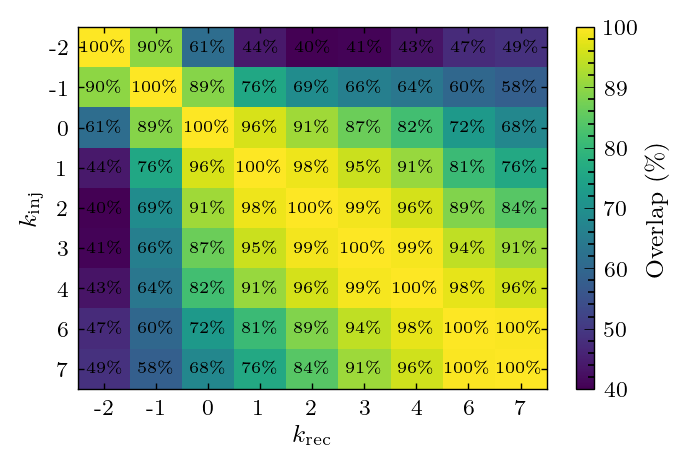

In [ ]:
kk = np.array(list(obj.k2str.keys()))
kkvals = kk[kk != 5]

obj.k2str[kkvals[0]]


res_allppe = {}
for i in range(len(kkvals)):
    k_inj = kkvals[i]
    res_allppe[obj.k2str[k_inj]] = get_stuff(k_inj)
    print(kkvals[i], res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'])

ff = np.zeros((len(kkvals),len(kkvals)),dtype=np.complex128)
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        norm_1 = res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'] 
        norm_2 = res_allppe[obj.k2str[kkvals[j]]]['snr_dhperp']
        dh_1 = res_allppe[obj.k2str[kkvals[i]]]["dh_perp"] 
        dh_2 = res_allppe[obj.k2str[kkvals[j]]]["dh_perp"] 
        

        ff[i,j] = np.sum([lib.innprod(dh_1[d], dh_2[d], obj.psdO3, obj.freqs) for d in dets])/norm_1/norm_2



import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter



fig = plt.figure(figsize = (my_width, my_width/golden),dpi=100)
ax = fig.gca()

mmarr = np.abs(ff)

# Ensure values are between 0 and 1 for percentage representation
mmarr_safe = np.clip(mmarr, 0, 1)

# Define levels for percentage scale (0% to 100%)
levels = np.linspace(0.4, 1, 7)
normbar = mcolors.Normalize(vmin=0.4, vmax=1)


# build mask: True where we want to grey out (row+col for k==0)
mask = np.zeros_like(mmarr_safe, dtype=bool)
if 0 in kkvals:
    idx0 = np.where(kkvals == 0)[0][0]
    # mask[idx0, :] = True
    # mask[:, idx0] = True

# masked array so imshow draws masked entries with the "bad" color
mmarr_masked = np.ma.array(mmarr_safe, mask=mask)
cmap = plt.cm.get_cmap("viridis")
cmap.set_bad(color="lightgray")    # masked cells will appear light gray

# Plot using percentage scale
# plt.imshow(mmarr_safe, cmap='viridis', interpolation='nearest', aspect='auto', norm=normbar)
plt.imshow(mmarr_masked, cmap=cmap, interpolation="nearest", aspect="auto", norm=normbar)


# Add discrete color bar
cbar = plt.colorbar(ticks=levels)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x * 100)}"))
cbar.set_label(r'Overlap (\%)')

# Label axes
plt.xlabel(r"$k_{\mathrm{rec}}$")
plt.ylabel(r"$k_{\mathrm{inj}}$")

# Annotate each cell with percentage values
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        if mask[i, j]:
            continue
        text = fr"{mmarr_safe[i, j] * 100:.0f}\%"  # Convert to percentage
        ax.text(j, i, text, ha="center", va="center", color="k", fontsize=6, weight="bold")

# Set tick labels
labels = kkvals #np.append(kkvals, "NVNL")
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Adjust tick parameters
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.tick_params(axis='x', length=2, width=0.5)  # Make x-tick marks smaller
ax.tick_params(axis='y', length=2, width=0.5)  # Make y-tick marks smaller

# plt.savefig("fig5-overlap-ppe-tests-gw150914-spin-measured.pdf", bbox_inches='tight', pad_inches=0)

plt.show()

##### GW overlap with no spin biases

In [40]:
names = ['M_c', 'eta', 'd_L', 'ra', 'dec', 'iota', 'psi', 't_c', 'phase_c']
data = [0,  0,  0, 1.85631014e+00, -7.31174691e-02,  1.05346794e+00, 9.79787100e-01,  0.00000000e+00,  0.00000000e+00]
# picked random angles here

# idx = '170817'
idx = '150914'
if idx=='150914':
    data = np.array(data)
    data[0] = 30
    q  = 0.79
    data[1] = q/(1+q)**2
    data[2] = 390
    dat = jnp.array(data)


red_param = dict(zip(names, jnp.array(dat).T))


epsilon = jnp.array(1e-6)
for key in ['s1_x', 's1_y', 's1_z', 's2_x', 's2_y', 's2_z']:
    red_param[key] = epsilon
zero_vector = jnp.array(0.)
for key in ['gmst', 'epoch']:
    red_param[key] = zero_vector

x = red_param.copy()
x['s1_z'] = 0.
x['s1_x'] = 0.

prec_pe = False
if prec_pe:
    i = None
else:
    i = -2
hgr = obj.get_h_gr(x)
dhgr = obj.get_dh_gr(x)
paramgr = obj.paramdiffgr.copy()[:i]
paramgr_latex = obj.paramdiffgr_latex.copy()[:i]
freqs = obj.freqs.copy()
dets = ["H1", "L1", "V1"]

-2 0.2974788872373636
-1 0.49072739105930585
0 0.6856796938959934
1 0.8577755646866054
2 0.9992526972529181
3 1.1083976394698742
4 1.1871700423806733
6 1.2715747032188864
7 1.287850204560691


/var/folders/8k/w_2008p52f36b9xbnhpbpp700000gn/T/ipykernel_31436/1333960174.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis")


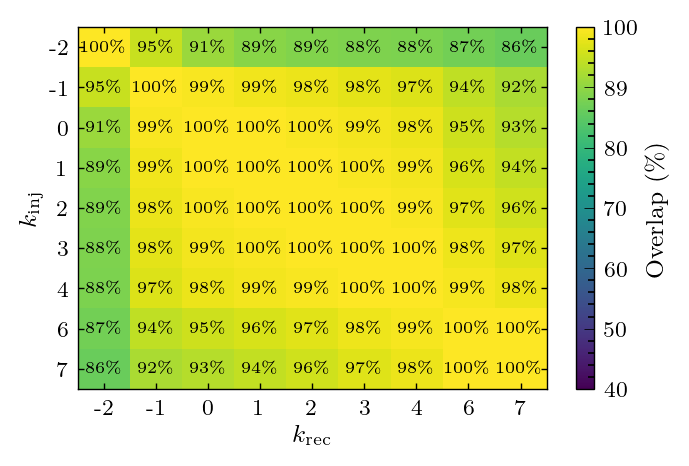

In [ ]:
kk = np.array(list(obj.k2str.keys()))
kkvals = kk[kk != 5]

obj.k2str[kkvals[0]]


res_allppe = {}
for i in range(len(kkvals)):
    k_inj = kkvals[i]
    res_allppe[obj.k2str[k_inj]] = get_stuff(k_inj)
    print(kkvals[i], res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'])

ff = np.zeros((len(kkvals),len(kkvals)),dtype=np.complex128)
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        norm_1 = res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'] 
        norm_2 = res_allppe[obj.k2str[kkvals[j]]]['snr_dhperp']
        dh_1 = res_allppe[obj.k2str[kkvals[i]]]["dh_perp"] 
        dh_2 = res_allppe[obj.k2str[kkvals[j]]]["dh_perp"] 
        

        ff[i,j] = np.sum([lib.innprod(dh_1[d], dh_2[d], obj.psdO3, obj.freqs) for d in dets])/norm_1/norm_2



import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter



fig = plt.figure(figsize = (my_width, my_width/golden),dpi=100)
ax = fig.gca()

mmarr = np.abs(ff)

# Ensure values are between 0 and 1 for percentage representation
mmarr_safe = np.clip(mmarr, 0, 1)

# Define levels for percentage scale (0% to 100%)
levels = np.linspace(0.4, 1, 7)
normbar = mcolors.Normalize(vmin=0.4, vmax=1)


# build mask: True where we want to grey out (row+col for k==0)
mask = np.zeros_like(mmarr_safe, dtype=bool)
if 0 in kkvals:
    idx0 = np.where(kkvals == 0)[0][0]
    # mask[idx0, :] = True
    # mask[:, idx0] = True

# masked array so imshow draws masked entries with the "bad" color
mmarr_masked = np.ma.array(mmarr_safe, mask=mask)
cmap = plt.cm.get_cmap("viridis")
cmap.set_bad(color="lightgray")    # masked cells will appear light gray

# Plot using percentage scale
# plt.imshow(mmarr_safe, cmap='viridis', interpolation='nearest', aspect='auto', norm=normbar)
plt.imshow(mmarr_masked, cmap=cmap, interpolation="nearest", aspect="auto", norm=normbar)


# Add discrete color bar
cbar = plt.colorbar(ticks=levels)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x * 100)}"))
cbar.set_label(r'Overlap (\%)')

# Label axes
plt.xlabel(r"$k_{\mathrm{rec}}$")
plt.ylabel(r"$k_{\mathrm{inj}}$")

# Annotate each cell with percentage values
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        if mask[i, j]:
            continue
        text = fr"{mmarr_safe[i, j] * 100:.0f}\%"  # Convert to percentage
        ax.text(j, i, text, ha="center", va="center", color="k", fontsize=6, weight="bold")

# Set tick labels
labels = kkvals #np.append(kkvals, "NVNL")
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Adjust tick parameters
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.tick_params(axis='x', length=2, width=0.5)  # Make x-tick marks smaller
ax.tick_params(axis='y', length=2, width=0.5)  # Make y-tick marks smaller

# plt.savefig("fig6-overlap-ppe-tests-gw150914-nospin-measured.pdf", bbox_inches='tight', pad_inches=0)

plt.show()

### GW170817 Overlap Plots

In [17]:
obj = lib.Fisher(fmin = 20, fmax = 5000, n_freq = 8000.)

##### GW170817 overlap with precession

In [33]:
names = ['M_c', 'eta', 'd_L', 'ra', 'dec', 'iota', 'psi', 't_c', 'phase_c']
data = [0,  0,  0, 1.85631014e+00, -7.31174691e-02,  1.05346794e+00, 9.79787100e-01,  0.00000000e+00,  0.00000000e+00]
# picked random angles here


idx = '170817'
if idx=='170817':
    data = np.array(data)
    data[0] = 1.1
    q  = 0.79
    data[1] = q/(1+q)**2
    data[2] = 40
    dat = jnp.array(data)


red_param = dict(zip(names, jnp.array(dat).T))


epsilon = jnp.array(1e-6)
for key in ['s1_x', 's1_y', 's1_z', 's2_x', 's2_y', 's2_z']:
    red_param[key] = epsilon
zero_vector = jnp.array(0.)
for key in ['gmst', 'epoch']:
    red_param[key] = zero_vector

x = red_param.copy()
x['s1_z'] = 0.
x['s1_x'] = 0.

prec_pe = True
if prec_pe:
    i = None
else:
    i = -2
hgr = obj.get_h_gr(x)
dhgr = obj.get_dh_gr(x)
paramgr = obj.paramdiffgr.copy()[:i]
paramgr_latex = obj.paramdiffgr_latex.copy()[:i]
freqs = obj.freqs.copy()
dets = ["H1", "L1", "V1"]

-2 0.09215634183579101
-1 0.03246151725620894
0 0.00020929072397692935
1 0.009373025913181886
2 0.005905930241984038
3 0.0017867961327781374
4 0.0034587593058828673
6 0.011535550152703142
7 0.009587756648908237


/var/folders/8k/w_2008p52f36b9xbnhpbpp700000gn/T/ipykernel_31436/3892335609.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis")


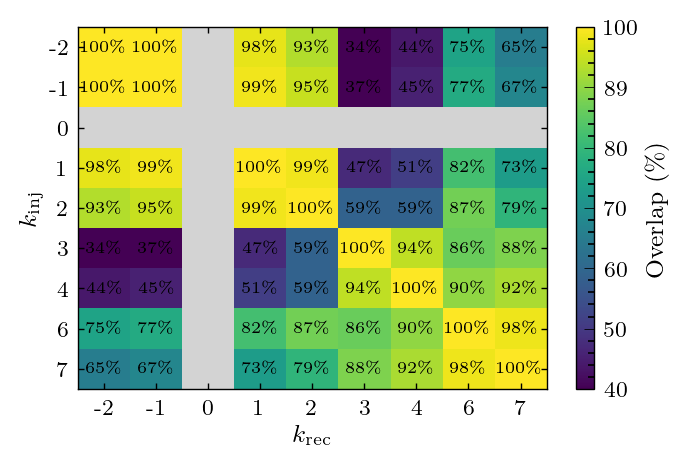

In [ ]:
kk = np.array(list(obj.k2str.keys()))
kkvals = kk[kk != 5]

obj.k2str[kkvals[0]]


res_allppe = {}
for i in range(len(kkvals)):
    k_inj = kkvals[i]
    res_allppe[obj.k2str[k_inj]] = get_stuff(k_inj)
    print(kkvals[i], res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'])

ff = np.zeros((len(kkvals),len(kkvals)),dtype=np.complex128)
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        norm_1 = res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'] 
        norm_2 = res_allppe[obj.k2str[kkvals[j]]]['snr_dhperp']
        dh_1 = res_allppe[obj.k2str[kkvals[i]]]["dh_perp"] 
        dh_2 = res_allppe[obj.k2str[kkvals[j]]]["dh_perp"] 
        

        ff[i,j] = np.sum([lib.innprod(dh_1[d], dh_2[d], obj.psdO3, obj.freqs) for d in dets])/norm_1/norm_2



import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter



fig = plt.figure(figsize = (my_width, my_width/golden),dpi=100)
ax = fig.gca()

mmarr = np.abs(ff)

# Ensure values are between 0 and 1 for percentage representation
mmarr_safe = np.clip(mmarr, 0, 1)

# Define levels for percentage scale (0% to 100%)
levels = np.linspace(0.4, 1, 7)
normbar = mcolors.Normalize(vmin=0.4, vmax=1)


# build mask: True where we want to grey out (row+col for k==0)
mask = np.zeros_like(mmarr_safe, dtype=bool)
if 0 in kkvals:
    idx0 = np.where(kkvals == 0)[0][0]
    mask[idx0, :] = True
    mask[:, idx0] = True

# masked array so imshow draws masked entries with the "bad" color
mmarr_masked = np.ma.array(mmarr_safe, mask=mask)
cmap = plt.cm.get_cmap("viridis")
cmap.set_bad(color="lightgray")    # masked cells will appear light gray

# Plot using percentage scale
# plt.imshow(mmarr_safe, cmap='viridis', interpolation='nearest', aspect='auto', norm=normbar)
plt.imshow(mmarr_masked, cmap=cmap, interpolation="nearest", aspect="auto", norm=normbar)


# Add discrete color bar
cbar = plt.colorbar(ticks=levels)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x * 100)}"))
cbar.set_label(r'Overlap (\%)')

# Label axes
plt.xlabel(r"$k_{\mathrm{rec}}$")
plt.ylabel(r"$k_{\mathrm{inj}}$")

# Annotate each cell with percentage values
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        if mask[i, j]:
            continue
        text = fr"{mmarr_safe[i, j] * 100:.0f}\%"  # Convert to percentage
        ax.text(j, i, text, ha="center", va="center", color="k", fontsize=6, weight="bold")

# Set tick labels
labels = kkvals #np.append(kkvals, "NVNL")
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Adjust tick parameters
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.tick_params(axis='x', length=2, width=0.5)  # Make x-tick marks smaller
ax.tick_params(axis='y', length=2, width=0.5)  # Make y-tick marks smaller

# plt.savefig("fig13a-overlap-ppe-tests-gw170817-spin-measured.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

##### GW170817 overlap with aligned spin

In [35]:
names = ['M_c', 'eta', 'd_L', 'ra', 'dec', 'iota', 'psi', 't_c', 'phase_c']
data = [0,  0,  0, 1.85631014e+00, -7.31174691e-02,  1.05346794e+00, 9.79787100e-01,  0.00000000e+00,  0.00000000e+00]
# picked random angles here


idx = '170817'
if idx=='170817':
    data = np.array(data)
    data[0] = 1.1
    q  = 0.79
    data[1] = q/(1+q)**2
    data[2] = 40
    dat = jnp.array(data)


red_param = dict(zip(names, jnp.array(dat).T))


epsilon = jnp.array(1e-6)
for key in ['s1_x', 's1_y', 's1_z', 's2_x', 's2_y', 's2_z']:
    red_param[key] = epsilon
zero_vector = jnp.array(0.)
for key in ['gmst', 'epoch']:
    red_param[key] = zero_vector

x = red_param.copy()
x['s1_z'] = 0.
x['s1_x'] = 0.

prec_pe = False
if prec_pe:
    i = None
else:
    i = -2
hgr = obj.get_h_gr(x)
dhgr = obj.get_dh_gr(x)
paramgr = obj.paramdiffgr.copy()[:i]
paramgr_latex = obj.paramdiffgr_latex.copy()[:i]
freqs = obj.freqs.copy()
dets = ["H1", "L1", "V1"]

-2 0.28825938642259546
-1 0.12205834713885513
0 0.0025573204910631295
1 0.06063902591473334
2 0.06745844045741274
3 0.03391366591986981
4 0.01005925553967607
6 0.034595211337317265
7 0.019888224518962102


/var/folders/8k/w_2008p52f36b9xbnhpbpp700000gn/T/ipykernel_31436/2191636839.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis")


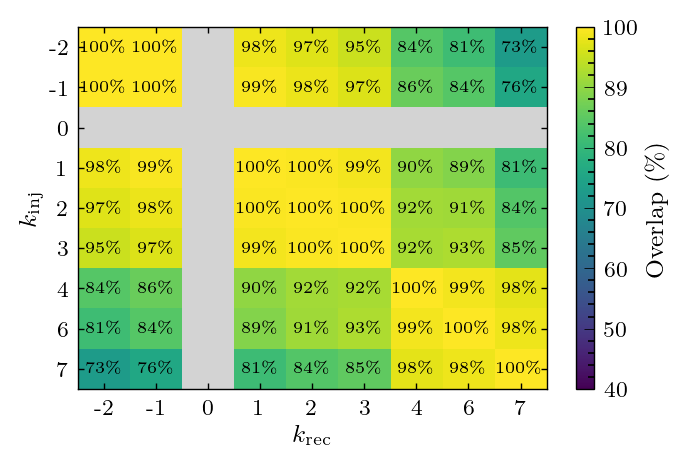

In [ ]:
kk = np.array(list(obj.k2str.keys()))
kkvals = kk[kk != 5]

obj.k2str[kkvals[0]]


res_allppe = {}
for i in range(len(kkvals)):
    k_inj = kkvals[i]
    res_allppe[obj.k2str[k_inj]] = get_stuff(k_inj)
    print(kkvals[i], res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'])

ff = np.zeros((len(kkvals),len(kkvals)),dtype=np.complex128)
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        norm_1 = res_allppe[obj.k2str[kkvals[i]]]['snr_dhperp'] 
        norm_2 = res_allppe[obj.k2str[kkvals[j]]]['snr_dhperp']
        dh_1 = res_allppe[obj.k2str[kkvals[i]]]["dh_perp"] 
        dh_2 = res_allppe[obj.k2str[kkvals[j]]]["dh_perp"] 
        

        ff[i,j] = np.sum([lib.innprod(dh_1[d], dh_2[d], obj.psdO3, obj.freqs) for d in dets])/norm_1/norm_2



import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter



fig = plt.figure(figsize = (my_width, my_width/golden),dpi=100)
ax = fig.gca()

mmarr = np.abs(ff)

# Ensure values are between 0 and 1 for percentage representation
mmarr_safe = np.clip(mmarr, 0, 1)

# Define levels for percentage scale (0% to 100%)
levels = np.linspace(0.4, 1, 7)
normbar = mcolors.Normalize(vmin=0.4, vmax=1)


# build mask: True where we want to grey out (row+col for k==0)
mask = np.zeros_like(mmarr_safe, dtype=bool)
if 0 in kkvals:
    idx0 = np.where(kkvals == 0)[0][0]
    mask[idx0, :] = True
    mask[:, idx0] = True

# masked array so imshow draws masked entries with the "bad" color
mmarr_masked = np.ma.array(mmarr_safe, mask=mask)
cmap = plt.cm.get_cmap("viridis")
cmap.set_bad(color="lightgray")    # masked cells will appear light gray

# Plot using percentage scale
# plt.imshow(mmarr_safe, cmap='viridis', interpolation='nearest', aspect='auto', norm=normbar)
plt.imshow(mmarr_masked, cmap=cmap, interpolation="nearest", aspect="auto", norm=normbar)


# Add discrete color bar
cbar = plt.colorbar(ticks=levels)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x * 100)}"))
cbar.set_label(r'Overlap (\%)')

# Label axes
plt.xlabel(r"$k_{\mathrm{rec}}$")
plt.ylabel(r"$k_{\mathrm{inj}}$")

# Annotate each cell with percentage values
for i in range(len(kkvals)):
    for j in range(len(kkvals)):
        if mask[i, j]:
            continue
        text = fr"{mmarr_safe[i, j] * 100:.0f}\%"  # Convert to percentage
        ax.text(j, i, text, ha="center", va="center", color="k", fontsize=6, weight="bold")

# Set tick labels
labels = kkvals #np.append(kkvals, "NVNL")
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Adjust tick parameters
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.tick_params(axis='x', length=2, width=0.5)  # Make x-tick marks smaller
ax.tick_params(axis='y', length=2, width=0.5)  # Make y-tick marks smaller

# plt.savefig("fig13b-overlap-ppe-tests-gw170817-nospin-measured.pdf", bbox_inches='tight', pad_inches=0)
plt.show()